# EPSP ratio comparison with Rodriguez-Moreno and Paulsen 2008 dataset

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

# Load in vitro data
invitro = pd.read_csv('data/invitro/paired_recordings.csv')
invitro = invitro[invitro.reference == "Rodriguez-Moreno and Paulsen 2008"]
invitro['std_epsp_ratio'] = invitro['sem_epsp_ratio'] * np.sqrt(invitro['sample_size'])
invitro

,protocol_id,pre_mtype,post_mtype,area,animal,age,frequency_train,dt_train,n_stimuli_train,n_sweep,period_sweep,mean_epsp_ratio,sem_epsp_ratio,sample_size,reference,notes,std_epsp_ratio
30,rmp08_01,L4PC,L23PC,SSC (barrel),mouse,P9 - P14,0.2,10,1,100,5,1.54,0.05,5,Rodriguez-Moreno and Paulsen 2008,MK-801 in PRESYNAPTIC pipette to block NMDA re...,0.111803
31,rmp08_02,L4PC,L23PC,SSC (barrel),mouse,P9 - P14,0.2,-15,1,100,5,0.76,0.06,6,Rodriguez-Moreno and Paulsen 2008,Not clear whether the presynaptic cell was pyr...,0.146969
32,rmp08_03,L4PC,L23PC,SSC (barrel),mouse,P9 - P14,0.2,-15,1,100,5,1.04,0.06,6,Rodriguez-Moreno and Paulsen 2008,MK-801 in PRESYNAPTIC pipette to block NMDA re...,0.146969


In [2]:
# Merge EPSP amplitude and EPSP slope datasets
df = pd.read_csv('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC.csv')
df_slope = pd.read_csv('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_slope.csv')
df_merge = pd.merge(df_slope, df[["epsp_before", "epsp_after", "epsp_ratio"]],
                    left_index=True, right_index=True, suffixes=('', '_amplitude'))
df_merge.to_csv('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_merge.csv')

df = pd.read_csv('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_mk801.csv')
df_slope = pd.read_csv('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_mk801_slope.csv')
df_merge = pd.merge(df_slope, df[["epsp_before", "epsp_after", "epsp_ratio"]],
                    left_index=True, right_index=True, suffixes=('', '_amplitude'))
df_merge.to_csv('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_merge_mk801.csv')

In [3]:
# Load Rodriguez-Moreno and Paulsen 2008 data
insilico_exp, insilico_out, insilico = load_insilico('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_merge.csv')
insilico_exp_mk801, insilico_out_mk801, insilico_mk801 = load_insilico('data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_merge_mk801.csv')

No outliers in data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_merge.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before_amplitude
40,98862,26642,0.2,-15,0.991855,2.058306
35,89866,18189,0.2,-15,0.810591,2.016484
81,89592,8635,0.2,-15,0.266172,1.302808
61,88884,120342,0.2,-15,0.845379,1.043908
98,97300,2957,0.2,-15,0.242989,1.312933


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,0.2,-15,0.84751,0.458407,0.045841,100


No outliers in data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_merge_mk801.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before_amplitude
197,97756,3466,0.2,-15,1.037797,2.394471
157,92614,7122,0.2,-15,1.094997,1.770617
31,91379,23322,0.2,10,0.925873,1.858048
48,95835,22055,0.2,10,1.259459,1.204701
63,95535,13744,0.2,10,1.074458,1.064256


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,0.2,-15,1.138278,0.427470,0.042747,100
1,0.2,10,1.534370,0.960812,0.096081,100


t-test results for dt_train = -15.000000: s = 1.159, p = 0.268
t-test results for dt_train = -15.000000: s = 1.334, p = 0.209
t-test results for dt_train = 10.000000: s = -0.052, p = 0.959


Text(0.5, 1.0, 'Frequency = 0.2 Hz')

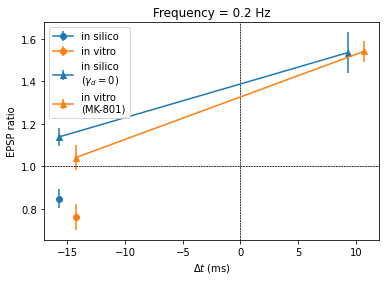

In [4]:
# Plot LTP freq
sel_invitro = invitro[invitro.protocol_id=='rmp08_02']
sel_insilico = insilico
fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train')

# Add MK801 data
sel_invitro = invitro[invitro.protocol_id!='rmp08_02']
sel_insilico = insilico_mk801
plot_ratio(sel_insilico, 'in silico\n($\gamma_d = 0)$', sel_invitro, 'in vitro\n(MK-801)',
           xvar='dt_train', marker='^', ax=ax)

if pubstyle:
    fig.set_size_inches(2.16535, 1.37795, forward=True)

ax.set_title('Frequency = 0.2 Hz')
#fig.savefig('l4_l23_stdp0p2.svg')

t-test results for dt_train = -15.000000: s = 1.159, p = 0.268
t-test results for dt_train = -15.000000: s = 1.334, p = 0.209
t-test results for dt_train = 10.000000: s = -0.052, p = 0.959


Text(0.5, 0.98, 'Frequency = 0.2 Hz\n')

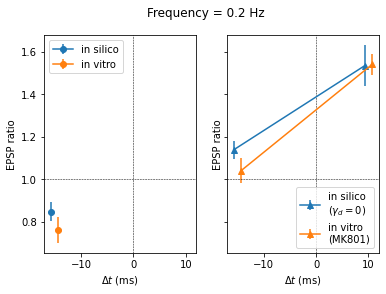

In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, sharex=True, sharey=True)

# Plot LTP freq
sel_invitro = invitro[invitro.protocol_id=='rmp08_02']
sel_insilico = insilico
fig, ax = plot_ratio(sel_insilico, 'in silico', sel_invitro, 'in vitro', xvar='dt_train', ax=ax0)
ax0.legend(loc=2)

# Add MK801 data
sel_invitro = invitro[invitro.protocol_id!='rmp08_02']
sel_insilico = insilico_mk801
plot_ratio(sel_insilico, 'in silico\n($\gamma_d = 0$)', sel_invitro, 'in vitro\n(MK801)',
           xvar='dt_train', marker='^', ax=ax1)
ax1.legend(loc=4)

if pubstyle:
    fig.set_size_inches(2.16535, 1.37795, forward=True)

fig.suptitle('Frequency = 0.2 Hz\n')

#fig.savefig('l4_l23_stdp0p2.svg')

Model fit: 0.74 (+/- 0.02) x ^ 0.00 (+/- 0.08)


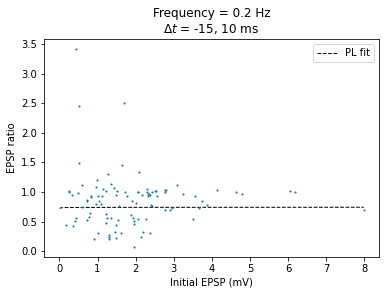

In [6]:
popt, perr = fit_powerlaw(insilico_exp.epsp_before_amplitude, insilico_exp.epsp_ratio)
print('Model fit: %.2f (+/- %.2f) x ^ %.2f (+/- %.2f)' % (popt[0], perr[0], popt[1], perr[1]))

x = np.linspace(0.0001, np.max(insilico_exp.epsp_before_amplitude), 100)

fig, ax = plt.subplots()
ax.scatter(insilico_exp.epsp_before_amplitude, insilico_exp.epsp_ratio, s=5, alpha=1, marker='.', c='C0')
ax.plot(x, powerlaw(x, *popt), lw=1, c='k', ls='dashed', label='PL fit', zorder=-1)

# Finalize plot
ax.legend()
ax.set_title('Frequency = 0.2 Hz\n' + r'$\Delta t$ = -15, 10 ms')
ax.set_ylabel('EPSP ratio')
ax.set_xlabel('Initial EPSP (mV)')
if pubstyle:
    fig.set_size_inches(1.16535, 1.37795, forward=True)

#fig.savefig('l4_l23_powerlaw.svg')

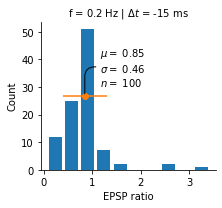

In [7]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                             "dt_train": "$\Delta t$",
                                             "epsp_ratio": "EPSP ratio"})

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l4_l23_rmp08_hist.png", dpi=300)

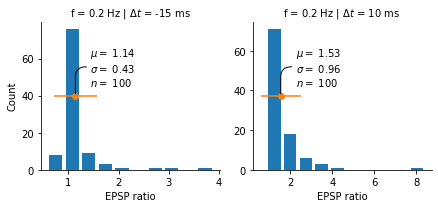

In [8]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = insilico_exp_mk801.rename(columns={"frequency_train": "f",
                                                  "dt_train": "$\Delta t$",
                                                  "epsp_ratio": "EPSP ratio"})

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

#g.savefig("l4_l23_rmp08_mk801_hist.png", dpi=300)